Q1. Dataset Overview 
Load the dataset and answer the following: 
 How many rows and columns are present?  
 What are the names of all columns?  
 Display the first 10 records. 

In [2]:
import pandas as pd 
dataset = pd.read_csv("agriculture_yield_dataset.csv")

print("Rows and Column : " , dataset.shape)
print("Columns" , dataset.columns)
dataset.head(10)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Rows and Column :  (1500, 8)
Columns Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='str')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


Q2. Data Types and Missing Values 
 Check the data type of each column.  
 Identify whether any missing values are present.  
 If missing values exist, mention the affected columns. 

In [12]:
print("datatype of columns" , dataset.dtypes , "\n")

missing_value = dataset.isnull().sum()
print(missing_value , "\n")

missing_cols = dataset.columns[missing_value > 0]

if len(missing_cols > 0):
    print("columns with missing value:")
    print(missing_cols.tolist())
else:
    print("no missing values")


datatype of columns rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object 

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64 

no missing values


Q3. Descriptive Statistics 
Generate summary statistics for all numerical features and answer: 
 Which feature has the highest mean value?  
 Which feature has the highest standard deviation?

In [23]:
print( dataset.describe(), "\n")

means = dataset.mean(numeric_only=True)
print("Highest mean feature:", means.idxmax() , "\n")


stds = dataset.std(numeric_only= True)
print("Highest standard deviation feature: ", stds.idxmax) 



       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

Part B: Exploratory Data Analysis (EDA) 
Q4. Distribution Analysis 
Create histograms for: 
 rainfall_mm  
 temperature_c  
 fertilizer_kg  
 yield_ton_per_hectare  
Write 2–3 observations from each histogram.

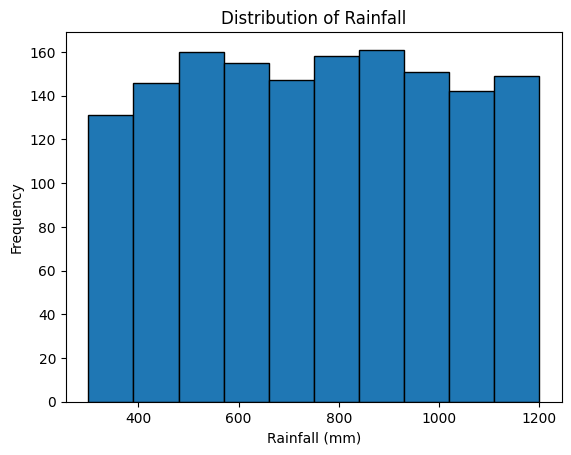

In [38]:

import matplotlib.pyplot as plt

plt.hist(dataset['rainfall_mm'], bins=10 , edgecolor = 'black')
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

#Rainfall is evenly distributed 
#there is no skewness , there is uniform distribution
#No highly concentrated rainfall range is observed


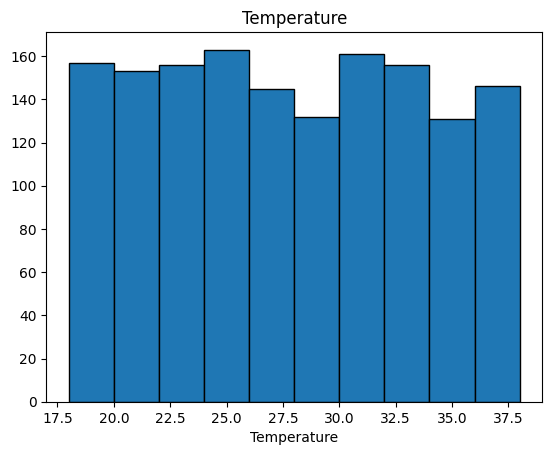

In [40]:
plt.hist(dataset['temperature_c'], bins=10 , edgecolor = 'black')
plt.title('Temperature')
plt.xlabel('Temperature')
plt.show()

#Temperatur values are spread across entire range
#The distribution is uniform 
#No outliers or skewness

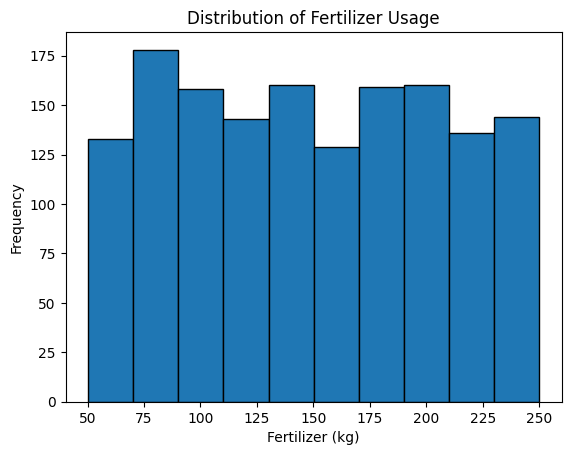

In [42]:
plt.hist(dataset['fertilizer_kg'] , edgecolor = 'black')
plt.title('Distribution of Fertilizer Usage')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Frequency')
plt.show()

#Fertilizer range is from 50 to 250 
# The distribution is uniform 
# No outlier or skewness

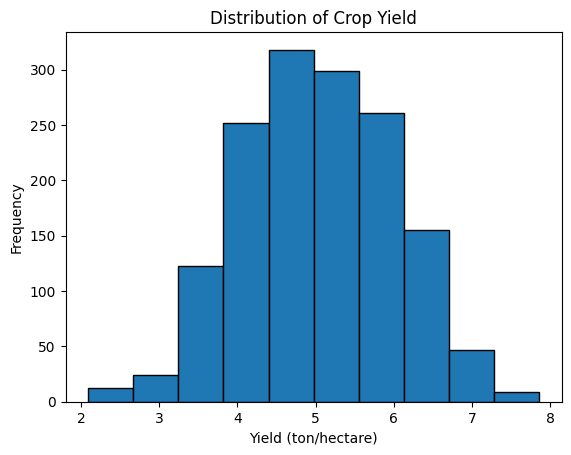

In [43]:
plt.hist(dataset['yield_ton_per_hectare'] , edgecolor = 'black')
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

#crop yield is highly concentrated from 4 to 6 ton/hectare
#This is normal distribution , bell shaped
#very low yield(2-3 ton/hectare) and very high yield(7-8 ton/hectare) is highly uncommon

Q5. Crop Type Analysis 
 Find the number of records for each crop type.  
 Create a count plot (bar chart) for crop_type.  
 Which crop appears most frequently? 

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


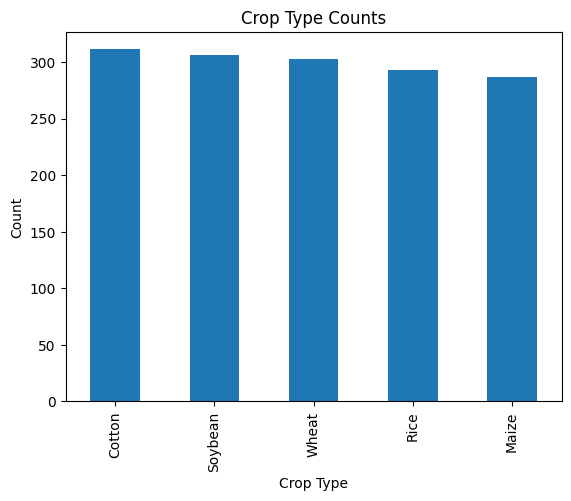

Most frequent crop:
Cotton


In [50]:
crop_counts = dataset["crop_type"].value_counts()
print(crop_counts)

crop_counts.plot(kind='bar')
plt.title('Crop Type Counts')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()

print("Most frequent crop:")
print(crop_counts.idxmax())


Q6. Soil Type Analysis 
 Find the frequency of each soil type.  
 Create a count plot for soil_type.  
 Which soil type is most common? 

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


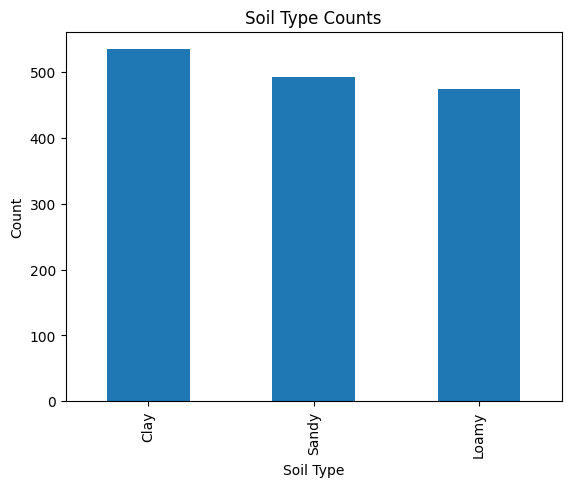

Most common soil:
Clay


In [54]:
soil_counts = dataset['soil_type'].value_counts()
print(soil_counts)

soil_counts.plot(kind='bar')
plt.title('Soil Type Counts')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()

print("Most common soil:")
print(soil_counts.idxmax())

Q7. Yield Distribution 
Create a histogram of yield_ton_per_hectare. 
Answer: 
 Is the distribution approximately normal?  
 Are there any noticeable outliers? 

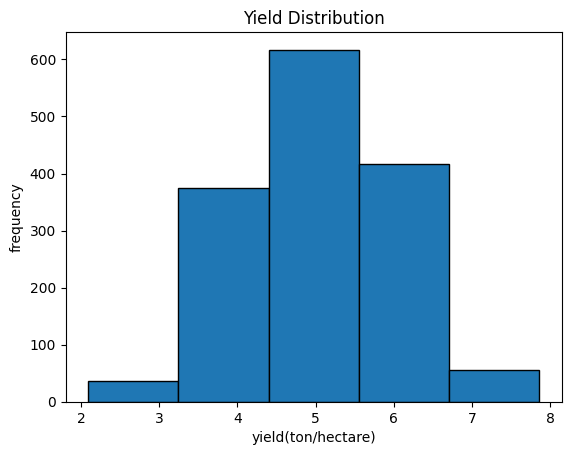

In [56]:
plt.hist(dataset['yield_ton_per_hectare'] , bins = 5 , edgecolor = 'black')
plt.xlabel('yield(ton/hectare)')
plt.ylabel('frequency')
plt.title('Yield Distribution')
plt.show()


#It's normal distribution , bell shaped 
#yes , there are

Q8. Scatter Plot Analysis 
Create scatter plots of: 
1. rainfall_mm vs yield_ton_per_hectare  
2. fertilizer_kg vs yield_ton_per_hectare  
Based on the plots: 
 Which feature appears to have a stronger relationship with yield? 

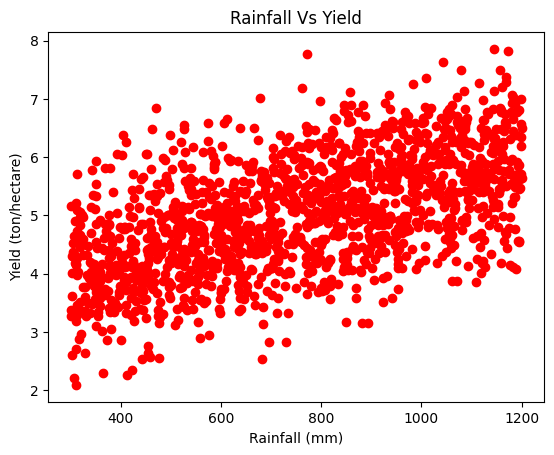

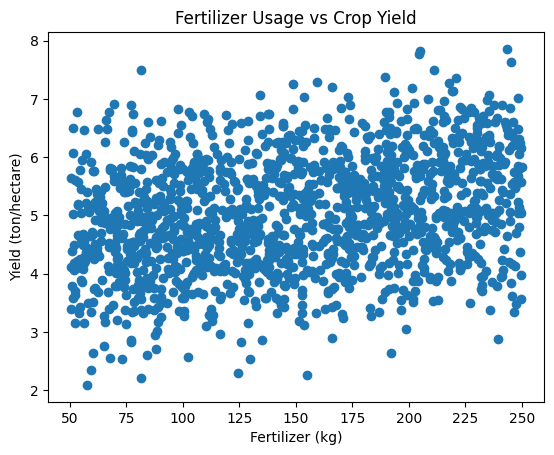

In [8]:
import matplotlib.pyplot as plt
plt.scatter(dataset['rainfall_mm'] , dataset["yield_ton_per_hectare"] , color = 'red')
plt.title("Rainfall Vs Yield")
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton/hectare)')
plt.show()



plt.scatter(dataset['fertilizer_kg'], dataset['yield_ton_per_hectare'])
plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton/hectare)')
plt.show()

Rainfall appears to have better relationship with yield based on the graphs

Q9. Correlation Analysis 
 Generate a correlation matrix for numerical features.  
 Create a heatmap.  
 Identify the top three features most correlated with crop yield.

In [13]:
corr_matrix = dataset.corr(numeric_only=True)
print(corr_matrix)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

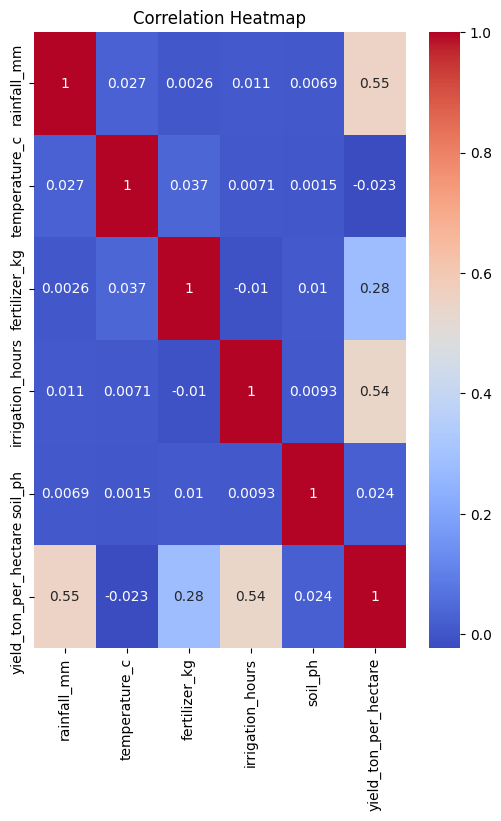

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt 

corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(6,8))
sns.heatmap(corr_matrix , annot=True , cmap ='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
corr_with_yield = corr_matrix['yield_ton_per_hectare']
print(corr_with_yield)


rainfall_mm              0.553704
temperature_c           -0.022559
fertilizer_kg            0.278043
irrigation_hours         0.542664
soil_ph                  0.024412
yield_ton_per_hectare    1.000000
Name: yield_ton_per_hectare, dtype: float64


Q10. Group-Based Analysis 
Calculate the average yield for: 
 Each crop type  
 Each soil type  
Which crop and soil type have the highest average yield? 

In [19]:
crop_yield = dataset.groupby('crop_type')["yield_ton_per_hectare"].mean()
print(crop_yield)

soil_yield = dataset.groupby('soil_type')["yield_ton_per_hectare"].mean()
print(soil_yield)

print("Crop Type which have the highest yield : ", crop_yield.idxmax())
print("Soil Type which have the highest yield : " , soil_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Crop Type which have the highest yield :  Rice
Soil Type which have the highest yield :  Loamy


Part C: Data Preparation 
Q11. Feature Encoding 
The dataset contains categorical variables. 
 Identify the categorical columns.  
 Convert them into numerical form using One-Hot Encoding.  
 Display the first five rows of the transformed dataset.

In [31]:
print(dataset.dtypes)

encoded_dataset = pd.get_dummies(dataset, columns=['crop_type' , 'soil_type'])
print(encoded_dataset.head())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                  int64
soil_type                  int64
yield_ton_per_hectare    float64
dtype: object
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_0  crop_type_1  crop_type_2  crop_type_3  \
0                   5.92        False         True        False        False   
1                   6.24        False         True        False        False   
2                   4.77       

Q12. Feature Selection 
Separate: 
 Input features (X)  
 Target variable (y)  
Specify which column is being used as the target variable.

In [33]:
X = encoded_dataset.drop('yield_ton_per_hectare', axis=1)
y = encoded_dataset['yield_ton_per_hectare']

Part D: Machine Learning 
Q13. Train-Test Split 
Split the dataset into: 
 80% Training Data  
 20% Testing Data  
Display the shape of: 
 X_train  
 X_test  
 y_train  
 y_test 

In [37]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size =0.2 , random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200, 13)
(300, 13)
(1200,)
(300,)


Q14. Linear Regression Model 
 Train a Linear Regression model.  
 Display the model coefficients and intercept.  
 Which feature has the highest positive coefficient?

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train , y_train)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

print("Interception" , model.intercept_)

highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print(highest_feature)



             Feature  Coefficient
0        rainfall_mm     0.002035
1      temperature_c    -0.009175
2      fertilizer_kg     0.004978
3   irrigation_hours     0.198327
4            soil_ph     0.004901
5        crop_type_0    -0.386623
6        crop_type_1    -0.147693
7        crop_type_2     0.477369
8        crop_type_3     0.095096
9        crop_type_4    -0.038149
10       soil_type_0     0.062653
11       soil_type_1     0.365627
12       soil_type_2    -0.428280
Interception 1.9111026182800752
Feature        crop_type_2
Coefficient       0.477369
Name: 7, dtype: object
